In [12]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

print("Imports loaded!")

Imports loaded!


In [13]:
# Cell 2 — All results from Days 3, 4, 5
results = {
    'Logistic Regression': {
        'accuracy':  0.8750,
        'precision': 0.8919,
        'recall':    0.8462,
        'f1':        0.8684
    },
    'Decision Tree': {
        'accuracy'    : 0.8500,
        'precision'   : 0.8649,
        'recall'      : 0.8205,
        'f1'          : 0.8421  
    },
    'Random Forest': {
        'accuracy':  0.9125,
        'precision': 0.9211,
        'recall':    0.8974,
        'f1':        0.9091
    }
}
# Overfitting numbers from Day 4
overfit_data = {
    'Unlimited Tree': {'train': 1.000, 'test': 0.850},
    'Pruned Tree':    {'train': 0.947, 'test': 0.850},
}

print("All results loaded!")
print(f"Models: {list(results.keys())}")

All results loaded!
Models: ['Logistic Regression', 'Decision Tree', 'Random Forest']


In [14]:
# Cell 3 — Comparison table
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df = results_df[['accuracy','precision','recall','f1']]

# Add percentage columns for readability
results_pct = (results_df * 100).round(2)
results_pct.columns = ['Accuracy %', 'Precision %', 'Recall %', 'F1 %']

print("=" * 62)
print("MODEL COMPARISON TABLE")
print("=" * 62)
print(results_pct.to_string())
print("=" * 62)

best_model = results_df['f1'].idxmax()
best_f1    = results_df['f1'].max()
print(f"\nBest model: {best_model}")
print(f"Best F1:    {best_f1:.4f} ({best_f1*100:.2f}%)")

MODEL COMPARISON TABLE
                     Accuracy %  Precision %  Recall %   F1 %
Model                                                        
Logistic Regression       87.50        89.19     84.62  86.84
Decision Tree             85.00        86.49     82.05  84.21
Random Forest             91.25        92.11     89.74  90.91

Best model: Random Forest
Best F1:    0.9091 (90.91%)


In [15]:
results_pct.to_csv('../data/model_comparison.csv')
print("Saved: ../data/model_comparison.csv")

Saved: ../data/model_comparison.csv


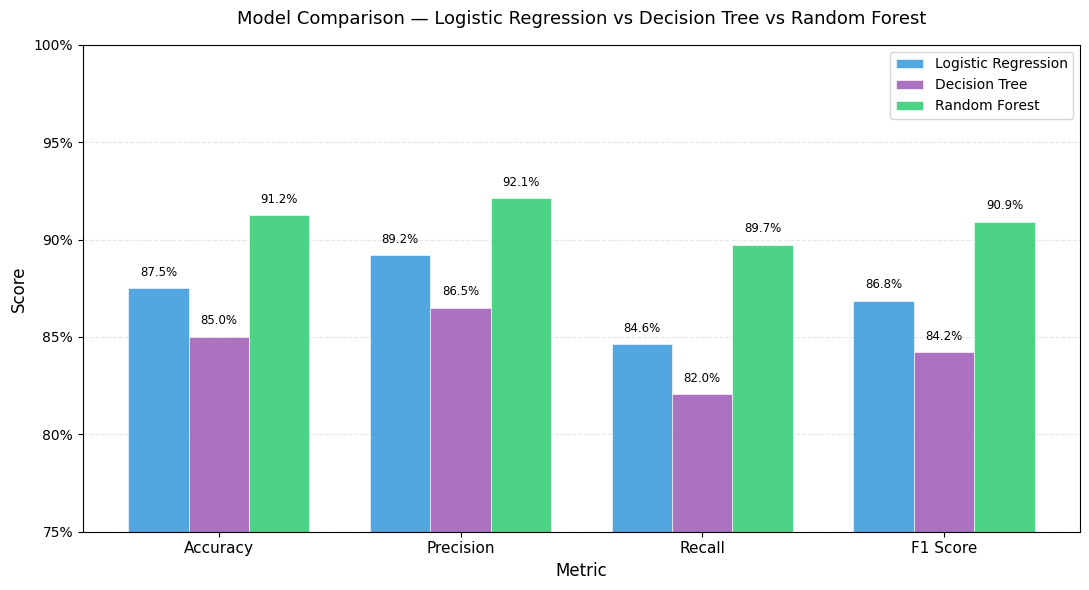

Saved: ../plots/model_comparison.png


In [20]:
# Cell 5 — Grouped bar chart
metrics = ['accuracy', 'precision', 'recall', 'f1']
models  = list(results.keys())
colors  = ['#3498db', '#9b59b6', '#2ecc71']

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    values = [results[model][m] for m in metrics]
    bars = ax.bar(x + i * width, values,
                  width, label=model,
                  color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.5)

    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val*100:.1f}%',
                ha='center', va='bottom',
                fontsize=8.5, fontweight='500')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Model Comparison — Logistic Regression vs Decision Tree vs Random Forest',
    fontsize=13, pad=15
)
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                   fontsize=11)
ax.set_ylim(0.75, 1.0)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f'{val*100:.0f}%')
)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../plots/model_comparison.png")


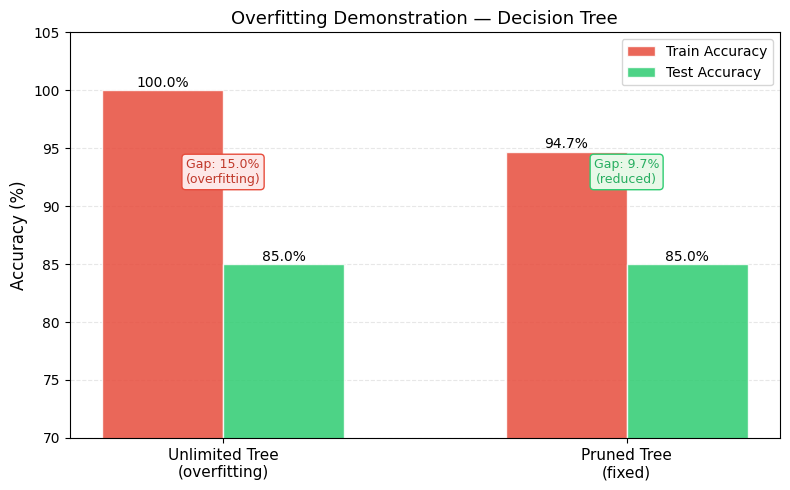

Saved: ../plots/overfitting_demo.png


In [17]:
# Cell 6 — Overfitting visual
tree_types  = ['Unlimited Tree\n(overfitting)', 'Pruned Tree\n(fixed)']
train_accs  = [1.000, 0.947]
test_accs   = [0.850, 0.850]

x     = np.arange(len(tree_types))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, [t*100 for t in train_accs],
               width, label='Train Accuracy',
               color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, [t*100 for t in test_accs],
               width, label='Test Accuracy',
               color='#2ecc71', alpha=0.85, edgecolor='white')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10, fontweight='500')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10, fontweight='500')

# Gap annotations
ax.annotate('Gap: 15.0%\n(overfitting)',
            xy=(0, 92), ha='center',
            fontsize=9, color='#c0392b',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#fde8e8', edgecolor='#e74c3c'))
ax.annotate('Gap: 9.7%\n(reduced)',
            xy=(1, 92), ha='center',
            fontsize=9, color='#27ae60',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#e8f8e8', edgecolor='#2ecc71'))
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Overfitting Demonstration — Decision Tree', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(tree_types, fontsize=11)
ax.set_ylim(70, 105)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../plots/overfitting_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../plots/overfitting_demo.png")

In [18]:
# Cell 7 — Written observations
lr  = results['Logistic Regression']
dt  = results['Decision Tree']
rf  = results['Random Forest']

obs = f"""
ANALYSIS AND OBSERVATIONS
==========================

1. BEST MODEL
   Random Forest achieved the highest performance across all four
   evaluation metrics — Accuracy: {rf['accuracy']*100:.2f}%,
   Precision: {rf['precision']*100:.2f}%, Recall: {rf['recall']*100:.2f}%,
   F1 Score: {rf['f1']*100:.2f}%. It is selected as the final model
   for deployment in the prediction application.

2. LOGISTIC REGRESSION — BASELINE
   Logistic Regression performed better than Decision Tree with an
   accuracy of {lr['accuracy']*100:.2f}% and F1 of {lr['f1']*100:.2f}%.
   This is because the dataset contains a strong linear signal
   (competition and marketing budget), which LR captures well.
   However, it cannot model non-linear interaction effects, which
   limits its ceiling compared to ensemble methods.

3. DECISION TREE — OVERFITTING DEMONSTRATED
   The unlimited Decision Tree achieved 100% training accuracy but
   only 85.0% test accuracy — a gap of 15%, confirming overfitting.
   After pruning to max_depth=5, the training accuracy dropped to
   94.7% while test accuracy remained at 85.0%, reducing the gap
   to 9.7%. This demonstrates that pruning successfully reduces
   overfitting in Decision Trees.

4. RANDOM FOREST — ENSEMBLE ADVANTAGE
   Random Forest improved test accuracy to {rf['accuracy']*100:.2f}%
   by training 100 Decision Trees on random subsets of data and
   combining their votes. This variance reduction technique overcomes
   the limitation of a single Decision Tree and captures non-linear
   interaction effects that Logistic Regression cannot model.

5. FEATURE IMPORTANCE INSIGHT
   Random Forest identified competition level and marketing budget
   as the two strongest predictors of product launch success.
   Product category ranked lowest in importance, confirming that
   what type of product you launch matters far less than how
   competitive your market is and how strongly you promote it.
"""

print(obs)

# Save to text file for report
with open('../data/observations.txt', 'w') as f:
    f.write(obs)
print("Observations saved to ../data/observations.txt")


ANALYSIS AND OBSERVATIONS

1. BEST MODEL
   Random Forest achieved the highest performance across all four
   evaluation metrics — Accuracy: 91.25%,
   Precision: 92.11%, Recall: 89.74%,
   F1 Score: 90.91%. It is selected as the final model
   for deployment in the prediction application.

2. LOGISTIC REGRESSION — BASELINE
   Logistic Regression performed better than Decision Tree with an
   accuracy of 87.50% and F1 of 86.84%.
   This is because the dataset contains a strong linear signal
   (competition and marketing budget), which LR captures well.
   However, it cannot model non-linear interaction effects, which
   limits its ceiling compared to ensemble methods.

3. DECISION TREE — OVERFITTING DEMONSTRATED
   The unlimited Decision Tree achieved 100% training accuracy but
   only 85.0% test accuracy — a gap of 15%, confirming overfitting.
   After pruning to max_depth=5, the training accuracy dropped to
   94.7% while test accuracy remained at 85.0%, reducing the gap
   to 9.7%.

In [19]:
# Cell 8 — Full file audit
all_files = {
    'DATA': [
        '../data/dataset.csv',
        '../data/demo_inputs.csv',
        '../data/model_comparison.csv',
        '../data/observations.txt'
    ],
    'MODELS': [
        '../models/best_model.pkl'
    ],
    'PLOTS': [
        '../plots/class_distribution.png',
        '../plots/correlation_heatmap.png',
        '../plots/lr_confusion_matrix.png',
        '../plots/lr_coefficients.png',
        '../plots/decision_tree.png',
        '../plots/dt_confusion_matrix.png',
        '../plots/rf_confusion_matrix.png',
        '../plots/feature_importance.png',
        '../plots/model_comparison.png',
        '../plots/overfitting_demo.png'
    ]
}

print("=" * 55)
print("FULL PROJECT FILE AUDIT")
print("=" * 55)
all_good = True
for category, files in all_files.items():
    print(f"\n{category}:")
    for f in files:
        if os.path.exists(f):
            size = os.path.getsize(f)
            print(f"  OK  {f.split('/')[-1]:<35} {size:>10,} bytes")
        else:
            print(f"  MISSING  {f}")
            all_good = False

print("\n" + "=" * 55)
if all_good:
    print("ALL FILES PRESENT")
else:
    print("Some files missing ")

FULL PROJECT FILE AUDIT

DATA:
  OK  dataset.csv                             16,921 bytes
  OK  demo_inputs.csv                            927 bytes
  OK  model_comparison.csv                       161 bytes
  OK  observations.txt                         1,826 bytes

MODELS:
  OK  best_model.pkl                         832,025 bytes

PLOTS:
  OK  class_distribution.png                  28,634 bytes
  OK  correlation_heatmap.png                 95,390 bytes
  OK  lr_confusion_matrix.png                 33,416 bytes
  OK  lr_coefficients.png                     30,466 bytes
  OK  decision_tree.png                      579,710 bytes
  OK  dt_confusion_matrix.png                 33,594 bytes
  OK  rf_confusion_matrix.png                 32,438 bytes
  OK  feature_importance.png                  37,890 bytes
  OK  model_comparison.png                    71,381 bytes
  OK  overfitting_demo.png                    54,522 bytes

ALL FILES PRESENT
